# Tutorial: Donor Effect Decomposition with LIVI using `cellink`

This tutorial demonstrates how to use **LIVI** (Latent Interaction Variational Inference) through the `cellink` package to decompose single-cell gene expression into cell-state-specific and persistent donor effects.

LIVI is a Variational Autoencoder (VAE)-based model that jointly learns:
- **Cell-state latent factors** (`z`): shared across donors, capturing transcriptional programs.
- **Donor × cell-state interaction factors** (`DxC`): how each donor's gene expression changes depending on the cell state they are in.
- **Persistent donor factors** (`V`): cell-state-independent donor effects (e.g. driven by population structure or persistent eQTLs).

After training, the learned donor embeddings can be tested for association with genotype data to identify trans-genetic effects on cell state. The `cellink` wrapper handles data preparation, training, inference and association testing directly from `DonorData`.

For installation of the LIVI repository, please refer to [https://github.com/PMBio/LIVI](https://github.com/PMBio/LIVI). The `cellink` wrapper requires the LIVI repository to be cloned locally; it does **not** need to be installed as a package.

## Environment Setup

We import the necessary libraries and define key analysis parameters. The only configuration LIVI requires beyond standard `cellink` setup is the path to the cloned LIVI repository.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

import cellink as cl
from cellink.resources import get_dummy_onek1k
from cellink.tl.external import (
    configure_livi_runner,
    infer_livi,
    load_livi_results,
    run_livi_association_testing,
    save_livi_results,
    train_livi,
)

# Path to the cloned LIVI repository
LIVI_ROOT = "/lustre/groups/ml01/workspace/lucas.arnoldt/projects/LIVI"

# Analysis parameters
n_gpcs = 20
celltype_key = "predicted.celltype.l2"
individual_col = "donor_id"

/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configure the LIVI Runner

The `LIVIRunner` manages the connection to the LIVI repository and the compute device. It needs to be configured once per session. The `execution_mode` controls how LIVI is invoked:

- `"python_api"` *(recommended)*: imports LIVI's PyTorch Lightning classes directly into the current Python process — no Hydra, no subprocess, results are Python objects.
- `"subprocess"`: runs LIVI's `src/train.py` CLI as a child process using Hydra configs; better suited for isolated HPC job submission.

The `device` parameter is set to `"auto"`, which detects a GPU if available and falls back to CPU otherwise.

In [2]:
runner = configure_livi_runner(
    livi_root=LIVI_ROOT,
    execution_mode="python_api",
    device="auto",
)
print(f"LIVI root: {runner.livi_root}")
print(f"Compute device: {runner.resolve_device()}")

LIVI root: /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/LIVI
Compute device: cuda


## Load and Prepare Data

We load the dummy OneK1K dataset, which contains both genotype and single-cell expression data for 100 donors. LIVI operates on the **cell-level AnnData** (`dd.C`) and requires raw counts. When a `DonorData` object is passed to LIVI functions, `dd.C` is used automatically and the `donor_id` key is inferred from `dd.donor_id`.

In [3]:
dd = get_dummy_onek1k(
    config_path="../../src/cellink/resources/config/dummy_onek1k.yaml",
    verify_checksum=False,
)
print(f"Dataset shape: {dd.shape}")
print(f"Cells: {dd.C.shape}, Donors: {dd.G.shape[0]}")

# Restrict genotype PCs to the first n_gpcs components
dd.G.obsm["gPCs"] = dd.G.obsm["gPCs"][dd.G.obsm["gPCs"].columns[:n_gpcs]]

[2026-05-19 04:10:24,485] INFO:root: /home/icb/lucas.arnoldt/cellink_data/dummy_onek1k/dummy_onek1k.dd.h5 already exists
[2026-05-19 04:10:24,486] WARNING:root: No checksum provided, skipping verification
[2026-05-19 04:10:41,521] INFO:root: Loaded dummy OneK1K dataset: (100, 146939, 125366, 34073)
Dataset shape: (100, 146939, 125366, 34073)
Cells: (125366, 34073), Donors: 100


## Data Preprocessing for LIVI

LIVI expects **raw integer counts** as input. We verify the data and optionally subset to a cell type of interest. LIVI handles all normalisation internally via learnable per-cell library-size factors.

In [4]:
# Propagate donor-level metadata (sex, age, pool batch) down to the cell level
dd.aggregate(obs=["donor_id", "sex", "age"], func="first", add_to_obs=True)

# Confirm that adata.X contains raw counts (LIVI requirement)
import scipy.sparse as sp
X_sample = dd.C.X[:100]
if sp.issparse(X_sample):
    X_sample = X_sample.toarray()
assert np.all(np.mod(X_sample, 1) == 0), "Non-integer values found — LIVI requires raw counts!"
print("Raw count check passed.")
print(f"Cells: {dd.C.shape[0]}, Genes: {dd.C.shape[1]}, Donors: {dd.G.shape[0]}")

Raw count check passed.
Cells: 125366, Genes: 34073, Donors: 100


We optionally filter to a single cell type. Fitting LIVI per cell type focuses the model on cell-state variation within a single lineage.

In [5]:
cell_type = "CD8 Naive"
dd_ct = dd[..., dd.C.obs[celltype_key] == cell_type, :].copy()
print(f"After filtering to '{cell_type}': {dd_ct.C.shape[0]} cells, {dd_ct.G.shape[0]} donors")

After filtering to 'CD8 Naive': 4756 cells, 100 donors


## Training LIVI

### Key Architecture Parameters

| Parameter | Meaning |
|---|---|
| `z_dim` | Number of cell-state latent factors (the VAE bottleneck) |
| `n_dxc_factors` | Number of donor × cell-state interaction (DxC) factors |
| `n_persistent_factors` | Number of persistent (cell-state-independent) donor factors |
| `warmup_epochs_vae` | Epochs to train only the VAE before activating donor effects |
| `warmup_epochs_G` | Additional epochs to train only `V` before activating `DxC` |

### Training Schedule

LIVI uses a three-phase warm-up to stabilise training:
1. **VAE pre-training** (`warmup_epochs_vae` epochs): only the encoder and base decoder are updated — the model learns cell-state factors without interference from donor effects.
2. **V training** (`warmup_epochs_G` epochs): the VAE is frozen; only persistent donor effects `V` are trained.
3. **Full model** (remaining epochs): DxC interaction factors are activated alongside `V`.

### Basic Training

The parameters below are scaled down for demonstration. In practice, use `z_dim=15`, `n_dxc_factors=300–700`, `max_epochs=400–600`, and `warmup_epochs_vae=60–90`.

In [6]:
checkpoint_path = train_livi(
    dd_ct,
    output_dir="livi_basic_run",
    # Architecture
    z_dim=5,               # cell-state latent dimensions (use 15 in practice)
    n_dxc_factors=20,      # DxC factors (use 300–700 in practice)
    n_persistent_factors=3, # persistent donor factors (use 5 in practice)
    encoder_hidden_dims=[256, 128, 64],  # encoder MLP widths
    # Data
    layer_key=None,        # None → uses dd.C.X (must be raw counts)
    use_size_factor=True,  # normalise by per-cell library size
    # Training schedule
    warmup_epochs_vae=5,
    warmup_epochs_G=0,
    max_epochs=15,
    min_epochs=5,
    # Optimiser
    learning_rate=8e-4,
    l1_weight=1e-3,
    A_weight=1e-3,
    # DataLoader
    batch_size=512,
    num_workers=0,
    seed=42,
)

print(f"Best checkpoint: {checkpoint_path}")

[2026-05-19 04:10:43,256] INFO:cellink.tl.external._livi: Using device: cuda
[2026-05-19 04:13:38,431] INFO:lightning_fabric.utilities.seed: Seed set to 42
[2026-05-19 04:13:51,288] INFO:pytorch_lightning.utilities.rank_zero: GPU available: True (cuda), used: True
[2026-05-19 04:13:51,289] INFO:pytorch_lightning.utilities.rank_zero: TPU available: False, using: 0 TPU cores
[2026-05-19 04:13:51,290] INFO:pytorch_lightning.utilities.rank_zero: HPU available: False, using: 0 HPUs
[2026-05-19 04:13:51,411] INFO:pytorch_lightning.utilities.rank_zero: You are using a CUDA device ('NVIDIA H100 80GB HBM3') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/ ...


[2026-05-19 04:14:09,356] INFO:pytorch_lightning.accelerators.cuda: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/livi_basic_run/checkpoints exists and is not empty.


[2026-05-19 04:14:12,210] INFO:pytorch_lightning.callbacks.model_summary: 
  | Name         | Type         | Params | Mode 
------------------------------------------------------
0 | encoder      | Encoder      | 8.8 M  | train
1 | decoder      | LIVI_Decoder | 988 K  | train
2 | D_context    | Embedding    | 2.0 K  | train
3 | V_persistent | Embedding    | 300    | train
  | other params | n/a          | 100    | n/a  
------------------------------------------------------
9.0 M     Trainable params
786 K     Non-trainable params
9.8 M     Total params
39.024    Total estimated model params size (MB)
20        Modules in train mode
0         Modules in eval mode
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/pytorch_lightning/utilities/data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.


/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 9/9 [00:50<00:00,  0.18it/s, v_num=4, train/elbo=-1.35e+4, train/L1_penalty_context=0.000, train/penalty_A=0.000, train/livi_loss=1.35e+4, hp_metric=1.35e+4]VAE frozen: False
Training V: False
Training DxC: False
DxC decoder requires grad: False
Epoch 1: 100%|██████████| 9/9 [00:00<00:00, 27.37it/s, v_num=4, train/elbo=-1.34e+4, train/L1_penalty_context=0.000, train/penalty_A=0.000, train/livi_loss=1.34e+4, hp_metric=1.34e+4]VAE frozen: False
Training V: False
Training DxC: False
DxC decoder requires grad: False
Epoch 2: 100%|██████████| 9/9 [00:00<00:00, 27.00it/s, v_num=4, train/elbo=-1.33e+4, train/L1_penalty_context=0.000, train/penalty_A=0.000, train/livi_loss=1.33e+4, hp_metric=1.33e+4]VAE frozen: False
Training V: False
Training DxC: False
DxC decoder requires grad: False
Epoch 3: 100%|██████████| 9/9 [00:00<00:00, 27.42it/s, v_num=4, train/elbo=-1.33e+4, train/L1_penalty_context=0.000, train/penalty_A=0.000, train/livi_loss=1.33e+4, hp_metric=1.33e+4]V

### Training with Batch Covariates

Technical covariates such as experimental pool or sequencing batch can be corrected for within LIVI via the `covariates_keys` parameter. Each key must be a categorical column in `dd.C.obs`. LIVI learns a per-gene additive correction for each category.

In [7]:
# Verify that the covariate columns exist in dd.C.obs
print("Available obs columns:", dd_ct.C.obs.columns.tolist())

# 'sex' is available in the dummy dataset
covariates = ["sex"]

checkpoint_with_covariates = train_livi(
    dd_ct,
    output_dir="livi_covariate_run",
    z_dim=5,
    n_dxc_factors=20,
    n_persistent_factors=3,
    covariates_keys=covariates,  # corrects for sex
    # covariates_dims is inferred from data if not provided
    layer_key=None,
    warmup_epochs_vae=5,
    max_epochs=15,
    batch_size=512,
    seed=42,
)

print(f"Best checkpoint (with covariates): {checkpoint_with_covariates}")

Available obs columns: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'donor_id', 'pool_number', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'age', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid']
[2026-05-19 04:15:32,100] INFO:cellink.tl.external._livi: Using device: cuda
[2026-05-19 04:15:32,101] INFO:lightning_fabric.utilities.seed: Seed set to 42
[2026-05-19 04:15:32,135] INFO:pytorch_lightning.utilities.rank_zero: GPU available: True (cuda), used: True
[2026-05-19 04:15:32,135] INFO:pytorch_lightning.utilities.rank_zero: TPU available: False, using: 0 TPU cores
[2026-05-19 04:15:32,

/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/ ...
/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/livi_covariate_run/checkpoints exists and is not empty.


/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/pytorch_lightning/utilities/data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.
/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 9/9 [00:00<00:00, 25.89it/s, v_num=3, train/elbo=-1.47e+4, train/L1_penalty_context=0.000, train/penalty_A=0.000, train/livi_loss=1.47e+4, hp_metric=1.47e+4]VAE frozen: False
Training V: False
Training DxC: False
DxC decoder requires grad: False
Epoch 1: 100%|██████████| 9/9 [00:00<00:00, 26.21it/s, v_num=3, train/elbo=-1.45e+4, train/L1_penalty_context=0.000, train/penalty_A=0.000, train/livi_loss=1.45e+4, hp_metric=1.45e+4]VAE frozen: False
Training V: False
Training DxC: False
DxC decoder requires grad: False
Epoch 2: 100%|██████████| 9/9 [00:00<00:00, 23.65it/s, v_num=3, train/elbo=-1.44e+4, train/L1_penalty_context=0.000, train/penalty_A=0.000, train/livi_loss=1.44e+4, hp_metric=1.44e+4]VAE frozen: False
Training V: False
Training DxC: False
DxC decoder requires grad: False
Epoch 3: 100%|██████████| 9/9 [00:00<00:00, 12.94it/s, v_num=3, train/elbo=-1.43e+4, train/L1_penalty_context=0.000, train/penalty_A=0.000, train/livi_loss=1.43e+4, hp_metric=1.43e+4]V

### Training with Known cis-eQTLs (using `dd.G` genotypes)

This mode jointly uses `dd.C` (expression) and `dd.G` (genotypes) to correct for local genetic effects during training, preventing cis-genetic variance from leaking into the donor embeddings.

Required inputs:

| Input | Shape | Source |
|---|---|---|
| `eqtl_genotypes` | donors × cis-SNPs | `dd.G.X` — auto-extracted when DonorData is passed **and `dd.G` has been pre-filtered to cis-SNPs** |
| `known_cis_eqtls` | cis-SNPs × genes (binary 0/1) | External annotation (GTEx, eQTL Catalogue); only genes with known cis-eQTLs needed |
| `n_cis_snps` | int | Number of cis-SNPs; must equal `dd.G.n_vars` when auto-extracting |

**Auto-extraction pattern (recommended for real analyses):**
Pre-filter `dd.G` to cis-SNPs only, then pass DonorData — `eqtl_genotypes` is auto-extracted:
```python
dd_cis = dd_ct[:, :, cis_snp_mask, :]          # subset dd.G to cis-SNPs
train_livi(dd_cis, ..., n_cis_snps=dd_cis.G.n_vars, known_cis_eqtls=annotation_df)
```

Below we build a small synthetic `known_cis_eqtls` and extract `eqtl_genotypes` from `dd.G.X` explicitly (since we are using a SNP subset for speed). The cell runs end-to-end on the dummy dataset.

In [8]:
from anndata.utils import asarray

# Use a small subset of SNPs from dd.G for the demo (50 SNPs for speed)
# In a real analysis, dd.G would be pre-filtered to cis-SNPs and the
# eqtl_genotypes auto-extraction would be used instead.
n_demo_snps = 50
demo_snps = dd_ct.G.var_names[:n_demo_snps]

# eqtl_genotypes: donors × cis-SNPs, extracted from dd.G.X
eqtl_genotypes_demo = pd.DataFrame(
    asarray(dd_ct.G.X[:, :n_demo_snps]),
    index=dd_ct.G.obs_names,
    columns=demo_snps,
)

# known_cis_eqtls: cis-SNPs × genes, binary (0/1)
# Rows = SNP IDs (must match eqtl_genotypes columns)
# Columns = gene IDs with known cis-associations (LIVI fills 0 for all other genes)
# In practice: derive from GTEx, eQTL Catalogue, or similar reference
rng = np.random.default_rng(42)
target_genes = dd_ct.C.var_names[:200]   # only a subset of genes needed
known_cis_eqtls_demo = pd.DataFrame(
    0, index=demo_snps, columns=target_genes, dtype=int
)
for snp in demo_snps:                    # assign each SNP to ~5 random genes
    hits = rng.choice(target_genes, size=5, replace=False)
    known_cis_eqtls_demo.loc[snp, hits] = 1

print(f"eqtl_genotypes:   {eqtl_genotypes_demo.shape}  (donors × cis-SNPs)")
print(f"known_cis_eqtls:  {known_cis_eqtls_demo.shape}  (cis-SNPs × genes with known associations)")

checkpoint_cis = train_livi(
    dd_ct,
    output_dir="livi_cis_run",
    z_dim=5,
    n_dxc_factors=20,
    n_persistent_factors=3,
    n_cis_snps=n_demo_snps,
    known_cis_eqtls=known_cis_eqtls_demo,   # SNPs × genes binary annotation
    eqtl_genotypes=eqtl_genotypes_demo,      # donors × SNPs from dd.G.X
    layer_key=None,
    covariates_keys=["sex"],
    warmup_epochs_vae=5,
    warmup_epochs_G=0,
    max_epochs=15,
    min_epochs=5,
    batch_size=512,
    cell_state_cis=True,   # learn cell-state-specific cis corrections per SNP
    seed=42,
)

print(f"Best checkpoint (cis-eQTL mode): {checkpoint_cis}")

eqtl_genotypes:   (100, 50)  (donors × cis-SNPs)
known_cis_eqtls:  (50, 200)  (cis-SNPs × genes with known associations)
[2026-05-19 04:15:55,172] INFO:cellink.tl.external._livi: Using device: cuda
[2026-05-19 04:15:55,172] INFO:lightning_fabric.utilities.seed: Seed set to 42
[2026-05-19 04:15:55,204] INFO:pytorch_lightning.utilities.rank_zero: GPU available: True (cuda), used: True
[2026-05-19 04:15:55,205] INFO:pytorch_lightning.utilities.rank_zero: TPU available: False, using: 0 TPU cores
[2026-05-19 04:15:55,205] INFO:pytorch_lightning.utilities.rank_zero: HPU available: False, using: 0 HPUs


/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/ ...


[2026-05-19 04:16:10,618] INFO:pytorch_lightning.accelerators.cuda: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
[2026-05-19 04:16:10,620] INFO:pytorch_lightning.callbacks.model_summary: 
  | Name             | Type         | Params | Mode 
----------------------------------------------------------
0 | encoder          | Encoder      | 17.6 M | train
1 | decoder          | LIVI_Decoder | 988 K  | train
2 | D_context        | Embedding    | 2.0 K  | train
3 | V_persistent     | Embedding    | 300    | train
4 | covariate_effect | Embedding    | 68.1 K | train
  | other params     | n/a          | 8.5 M  | n/a  
----------------------------------------------------------
17.9 M    Trainable params
9.3 M     Non-trainable params
27.2 M    Total params
108.691   Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/livi_cis_run/checkpoints exists and is not empty.


/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/pytorch_lightning/utilities/data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.
/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 0:  56%|█████▌    | 5/9 [00:01<00:01,  3.30it/s, v_num=3]

/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 512. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


Epoch 0: 100%|██████████| 9/9 [00:01<00:00,  5.37it/s, v_num=3, train/elbo=-1.47e+4, train/L1_penalty_context=0.000, train/penalty_A=0.000, train/livi_loss=1.47e+4, hp_metric=1.47e+4]VAE frozen: False
Training V: False
Training DxC: False
DxC decoder requires grad: False
Epoch 1: 100%|██████████| 9/9 [00:00<00:00, 24.76it/s, v_num=3, train/elbo=-1.45e+4, train/L1_penalty_context=0.000, train/penalty_A=0.000, train/livi_loss=1.45e+4, hp_metric=1.45e+4]VAE frozen: False
Training V: False
Training DxC: False
DxC decoder requires grad: False
Epoch 2: 100%|██████████| 9/9 [00:00<00:00, 24.14it/s, v_num=3, train/elbo=-1.44e+4, train/L1_penalty_context=0.000, train/penalty_A=0.000, train/livi_loss=1.44e+4, hp_metric=1.44e+4]VAE frozen: False
Training V: False
Training DxC: False
DxC decoder requires grad: False
Epoch 3: 100%|██████████| 9/9 [00:00<00:00, 24.05it/s, v_num=3, train/elbo=-1.43e+4, train/L1_penalty_context=0.000, train/penalty_A=0.000, train/livi_loss=1.43e+4, hp_metric=1.43e+4]V

### Dry Run: Inspect Configuration Without Training

Pass `run=False` to print the resolved model dimensions and return `None` without running any training. This is useful for verifying that `x_dim` and `y_dim` are inferred correctly before launching a long job.

In [9]:
train_livi(
    dd_ct,
    output_dir="livi_dryrun",
    z_dim=15,
    n_dxc_factors=300,
    n_persistent_factors=5,
    covariates_keys=["sex"],
    max_epochs=400,
    run=False,  # inspect config only
)

[2026-05-19 04:16:36,782] INFO:cellink.tl.external._livi: LIVI training config (run=False):
  x_dim=34073, y_dim=100, z_dim=15
  n_dxc_factors=300, n_persistent_factors=5, n_cis_snps=0
  encoder_hidden_dims=[512, 256, 64], learning_rate=0.0008
  covariates_keys=['sex'], covariates_dims=[2]


## Inference: Extracting Latent Factors

`infer_livi` loads a trained checkpoint and runs batch-wise inference to extract all latent representations. It returns a dictionary of DataFrames:

| Key | Shape | Content |
|---|---|---|
| `cell_state_latent` | n_cells × z_dim | Cell-state factor scores per cell |
| `cell_state_decoder` | n_genes × z_dim | Gene loadings of the cell-state decoder |
| `D_embedding` | n_donors × n_DxC | Donor × cell-state interaction embeddings |
| `DxC_decoder` | n_genes × n_DxC | Gene loadings of the DxC decoder |
| `V_embedding` | n_donors × n_V | Persistent donor factor embeddings |
| `V_decoder` | n_genes × n_V | Gene loadings of the V decoder |
| `assignment_matrix` | z_dim × n_DxC | Assignment matrix *A* linking cell-state to DxC factors |

> **Important**: inference should be run on the **same AnnData** (same donors, same cell order) as used for training so that the donor embedding indices align correctly.

In [10]:
results = infer_livi(
    dd_ct,
    checkpoint_path=checkpoint_path,
    batch_size=50_000,   # cells per inference batch
)

print("Inference outputs:")
for key, df in results.items():
    print(f"  {key}: {df.shape}")

[2026-05-19 04:16:38,013] INFO:cellink.tl.external._livi: Loading LIVI checkpoint: /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/livi_basic_run/checkpoints/epoch=0005_hp_metric=13169.04297-v3.ckpt
Inference outputs:
  cell_state_latent: (4756, 5)
  cell_state_decoder: (34073, 5)
  D_embedding: (100, 20)
  DxC_decoder: (34073, 20)
  assignment_matrix: (5, 20)
  V_embedding: (100, 3)
  V_decoder: (34073, 3)


### Cell-State Latent Factors

Each row is a cell; each column is a learned cell-state factor. These capture transcriptional programs that are shared across donors and can be used as input for downstream analyses such as UMAP or differential state testing.

In [11]:
cell_state = results["cell_state_latent"]
print(f"Cell-state factors: {cell_state.shape}")
cell_state.head()

Cell-state factors: (4756, 5)


,Cell-state_Factor1,Cell-state_Factor2,Cell-state_Factor3,Cell-state_Factor4,Cell-state_Factor5
barcode,,,,,
GTCTTCGGTCTCAACA-15,-1.462422,1.417718,1.329617,1.447212,-2.821284
ATCATCTTCTCTAAGG-15,-2.172364,1.649077,1.678022,0.419321,-3.379327
TAAACCGAGAGCTTCT-15,-1.448342,1.537536,1.370998,1.268712,-1.744996
CTGCCTATCGCGTAGC-15,-1.565268,1.781292,1.611772,0.899415,-2.424921
ACACCGGCAGCTGTAT-15,-0.641690,1.256412,1.164480,0.590716,-3.458261


We can add the cell-state factors directly to the AnnData for downstream analysis and UMAP visualisation.

... storing 'donor_id' as categorical
... storing 'chrom' as categorical


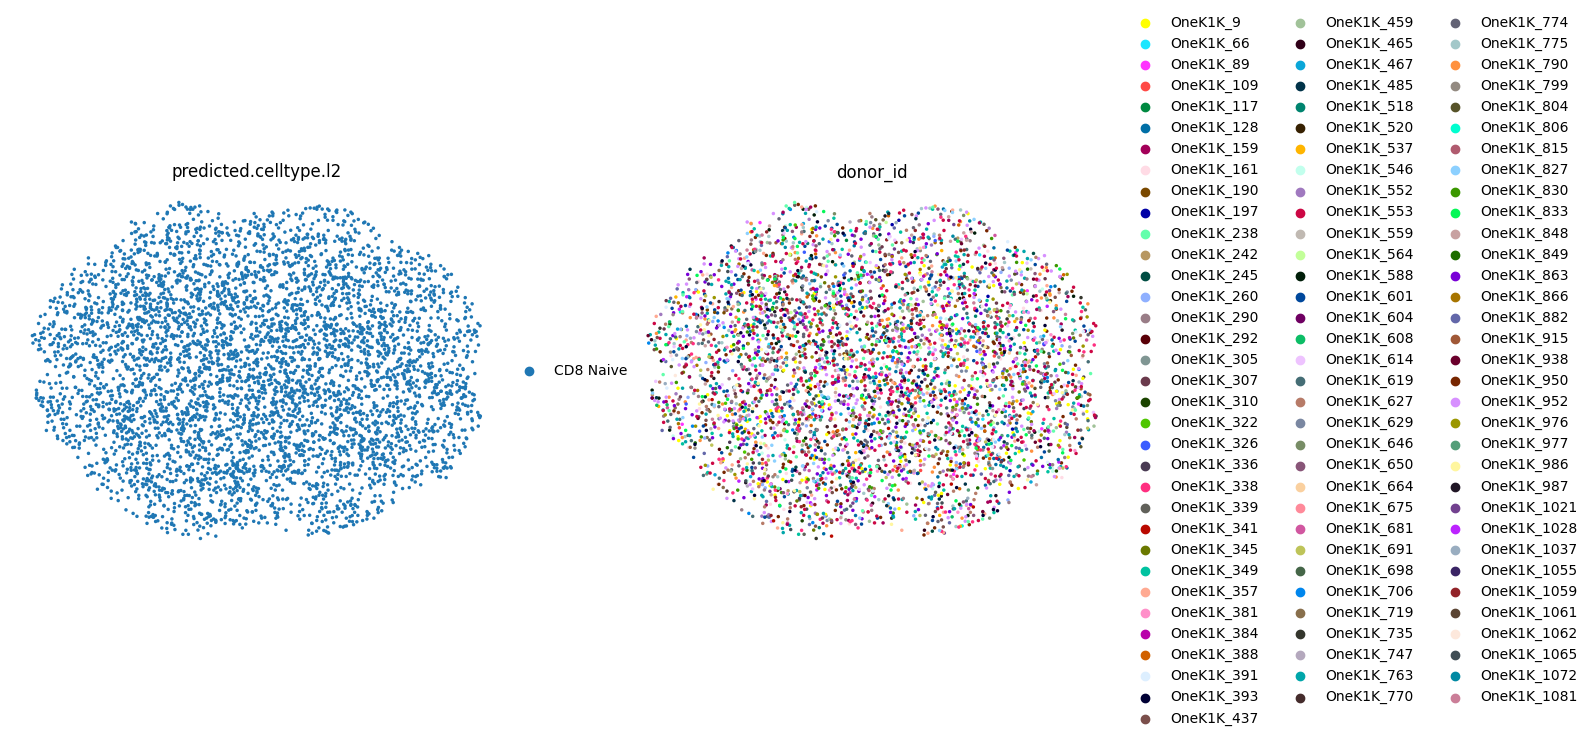

In [12]:
# Add cell-state factors to adata as an obsm embedding
dd_ct.C.obsm["X_livi"] = cell_state.loc[dd_ct.C.obs_names].values

# Compute neighbours and UMAP from LIVI factors
sc.pp.neighbors(dd_ct.C, use_rep="X_livi", n_neighbors=15)
sc.tl.umap(dd_ct.C)
sc.pl.umap(dd_ct.C, color=[celltype_key, "donor_id"], frameon=False)

### Donor Embeddings

The **D embedding** captures how each donor's gene expression is modulated by their cell state. Each row is a donor; each column is a learned DxC interaction factor.

In [13]:
D_embedding = results["D_embedding"]
print(f"D embedding (donor × DxC): {D_embedding.shape}")
D_embedding.head()

D embedding (donor × DxC): (100, 20)


,D_Factor1,D_Factor2,D_Factor3,D_Factor4,D_Factor5,D_Factor6,D_Factor7,D_Factor8,D_Factor9,D_Factor10,D_Factor11,D_Factor12,D_Factor13,D_Factor14,D_Factor15,D_Factor16,D_Factor17,D_Factor18,D_Factor19,D_Factor20
OneK1K_806,-0.974768,0.159784,0.340459,-0.441651,-0.751118,0.155192,-0.587765,2.002751,-0.134044,1.014944,-1.421716,1.524372,-0.895342,1.365174,0.138784,1.262102,1.078954,0.802033,-0.626433,0.818369
OneK1K_518,-1.229630,-1.945266,-0.287495,-0.030306,-0.370784,0.395173,-0.172822,-0.407377,0.516384,-0.675817,-2.204400,-0.986176,-0.159335,0.425176,2.256682,-0.887172,-0.108765,3.087630,0.814151,-0.726393
OneK1K_161,0.900962,0.641503,0.147291,-0.946515,1.058535,0.860771,0.966426,0.095665,0.381243,0.750093,0.878632,2.697427,-0.812763,-0.835455,-0.368005,-0.704610,1.117908,-1.179999,0.442890,1.511170
OneK1K_588,0.217726,2.105187,-1.300330,0.159082,0.181586,1.037446,0.594704,0.480849,0.478179,0.220334,0.495878,-1.280995,-0.195129,-0.500481,-1.654667,0.462433,-0.622641,-0.307051,-0.017201,-0.491066
OneK1K_1061,-0.249885,1.594545,0.220458,0.179075,-0.422622,-0.123294,-0.599741,0.177485,-0.898265,1.326377,1.549693,0.186060,0.061408,0.781149,0.281020,1.878345,0.645965,-1.368325,-1.574651,-1.371478


The `variance_threshold` argument retains only D factors with sufficient variability across donors, reducing noise in downstream association testing.

In [14]:
results_filtered = infer_livi(
    dd_ct,
    checkpoint_path=checkpoint_path,
    variance_threshold=0.01,  # keep only variable D factors
)

print("All D factors:     ", results["D_embedding"].shape)
print("Variable D factors:", results_filtered["D_embedding"].shape)

[2026-05-19 04:20:41,276] INFO:cellink.tl.external._livi: Loading LIVI checkpoint: /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/livi_basic_run/checkpoints/epoch=0005_hp_metric=13169.04297-v3.ckpt
All D factors:      (100, 20)
Variable D factors: (100, 20)


## Association Testing: Linking Donor Embeddings to Genotype

LIVI's donor embeddings can be treated as quantitative traits and tested for association with genetic variants. `run_livi_association_testing` tests each D and V factor against all SNPs using either:

- `"LMM"` (LIMIX): a linear mixed model that accounts for sample relatedness via a kinship matrix — recommended for cohorts with population structure.
- `"TensorQTL"`: fast GPU-accelerated testing without relatedness correction.

**When a `DonorData` object is passed as `genotype_matrix`, the wrapper automatically extracts:**
- `dd.G.X` → donors × SNPs genotype matrix
- `dd.G.uns["kinship"]` → kinship / GRM matrix (used for `method="LMM"`)
- `dd.G.obsm["gPCs"]` → genotype PCs (used as covariates)

You can always override any of these by passing `kinship=` or `genotype_pcs=` explicitly.

In [15]:
# Pass DonorData directly — dd.G.X, dd.G.uns["kinship"], and dd.G.obsm["gPCs"]
# are all extracted automatically.
associations = run_livi_association_testing(
    inference_results=results,
    genotype_matrix=dd,          # DonorData: dd.G is used for genotypes + kinship + gPCs
    output_dir="livi_associations",
    method="LMM",
    fdr_threshold=0.05,
    fdr_method="Benjamini-Hochberg",
    quantile_norm=True,
    output_file_prefix="demo",
)

# Returns a tuple (DxC_results, V_results) when both D and V embeddings are present
DxC_assoc, V_assoc = associations if isinstance(associations, tuple) else (associations, None)
print(f"DxC associations: {DxC_assoc.shape if DxC_assoc is not None else 'None'}")
print(f"V associations:   {V_assoc.shape if V_assoc is not None else 'None'}")

[2026-05-19 04:21:14,550] INFO:rpy2.situation: cffi mode is CFFI_MODE.ANY
[2026-05-19 04:21:14,555] INFO:rpy2.situation: R home found: /lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/R
[2026-05-19 04:21:14,814] INFO:rpy2.situation: R library path: 
[2026-05-19 04:21:14,814] INFO:rpy2.situation: LD_LIBRARY_PATH: 
[2026-05-19 04:21:15,405] INFO:rpy2.rinterface_lib.embedded: Default options to initialize R: rpy2, --quiet, --no-save
[2026-05-19 04:21:16,372] INFO:rpy2.rinterface: Environment variable "PWD" redefined by R and overriding existing variable. Current: "/ictstr01/home/icb/lucas.arnoldt", R: "/ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials"
[2026-05-19 04:21:17,482] INFO:rpy2.rinterface: R is already initialized. No need to initialize.
[2026-05-19 04:21:38,667] INFO:lightning_fabric.utilities.seed: Seed set to 32

 ----- Running genetic association testing for D embedding ----- 

Testing: D_Factor1


/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (100). n_quantiles is set to n_samples.


Testing: D_Factor2


/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (100). n_quantiles is set to n_samples.


Testing: D_Factor3


...

Testing: V_Factor2


/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (100). n_quantiles is set to n_samples.


Testing: V_Factor3


/lustre/groups/ml01/workspace/lucas.arnoldt/LIVIenv/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (100). n_quantiles is set to n_samples.


number of fQTLs: 1128
number of unique fSNPs: 1128
number of unique factors: 3
----- Done ----- 

DxC associations: (4676, 6)
V associations:   (1128, 6)


In [16]:
if DxC_assoc is not None:
    DxC_assoc.head()

### Explicit Component Override

When you need more control — e.g. a subset of SNPs or a different kinship — you can pass components individually instead of using `DonorData`. All three (genotype matrix, kinship, genotype PCs) can be overridden independently while still passing `dd` for the rest.

In [17]:
# Example: override genotype PCs but still pass dd for genotype matrix and kinship
# gPCs = dd.G.obsm["gPCs"]   # already extracted automatically when passing dd,
#                              # but you could subset or replace it here

# --- TensorQTL: pass components explicitly (no kinship needed) ---
#
# from anndata.utils import asarray
# GT_matrix = pd.DataFrame(
#     asarray(dd.G.X), index=dd.G.obs_names, columns=dd.G.var_names
# )
# gPCs = dd.G.obsm["gPCs"]
#
# associations_tensorqtl = run_livi_association_testing(
#     inference_results=results,
#     genotype_matrix=GT_matrix,   # explicit DataFrame
#     output_dir="livi_associations_tensorqtl",
#     method="TensorQTL",
#     genotype_pcs=gPCs,
#     fdr_threshold=0.05,
#     quantile_norm=True,
# )

## Saving and Loading Results

`save_livi_results` writes all inference DataFrames to TSV files in a single directory. `load_livi_results` reads them back, allowing you to restart downstream analyses without re-running inference.

In [18]:
# Save
saved_paths = save_livi_results(
    results,
    output_dir="livi_results",
    prefix="cd8_naive",
)
print("Saved files:")
for key, path in saved_paths.items():
    print(f"  {key}: {path}")

[2026-05-19 04:32:58,752] INFO:cellink.tl.external._livi: Saved cell_state_latent → livi_results/cd8_naive_cell_state_latent.tsv
[2026-05-19 04:32:58,836] INFO:cellink.tl.external._livi: Saved cell_state_decoder → livi_results/cd8_naive_cell_state_decoder.tsv
[2026-05-19 04:32:58,857] INFO:cellink.tl.external._livi: Saved D_embedding → livi_results/cd8_naive_D_embedding.tsv
[2026-05-19 04:32:59,181] INFO:cellink.tl.external._livi: Saved DxC_decoder → livi_results/cd8_naive_DxC_decoder.tsv
[2026-05-19 04:32:59,191] INFO:cellink.tl.external._livi: Saved assignment_matrix → livi_results/cd8_naive_assignment_matrix.tsv
[2026-05-19 04:32:59,287] INFO:cellink.tl.external._livi: Saved V_embedding → livi_results/cd8_naive_V_embedding.tsv
[2026-05-19 04:32:59,358] INFO:cellink.tl.external._livi: Saved V_decoder → livi_results/cd8_naive_V_decoder.tsv
Saved files:
  cell_state_latent: livi_results/cd8_naive_cell_state_latent.tsv
  cell_state_decoder: livi_results/cd8_naive_cell_state_decoder.tsv


In [19]:
# Load back
results_loaded = load_livi_results("livi_results", prefix="cd8_naive")
print("Loaded DataFrames:", list(results_loaded.keys()))

Loaded DataFrames: ['cell_state_latent', 'cell_state_decoder', 'D_embedding', 'DxC_decoder', 'V_embedding', 'V_decoder', 'assignment_matrix']
